# Marketing Campaign Analysis
## Phase 5 — Sentiment analysis

**Data source:** reviews table in marketing_db (PostgreSQL)
**Goal:** Build a text classifier that identifies customer complaints (Negative reviews) from Amazon product review text. The business question is **"which sentiment model best identifies complaints?"** — that question shapes how the model is selected.

### What this phase does
- Load cleaned reviews from PostgreSQL (Phase 2 already de-duplicated and filtered short reviews)
- Preprocess text: lowercase, remove punctuation and stopwords, stem
- Vectorise with TF-IDF (unigrams + bigrams)
- Train three classifiers — Naive Bayes, Logistic Regression, Linear SVC
- Evaluate in strict order: **confusion matrix → classification report → AUC-ROC**
- Select the model that best matches the stated business objective: **highest Negative-class recall**, not highest accuracy
- Surface the most informative words per sentiment and identify the dominant complaint theme

### Why per-class recall drives selection
The dataset is ~90% Positive. Accuracy on a 90/5/5 imbalance is dominated by the Positive class — a model that calls everything Positive gets 90% accuracy without finding a single complaint. Since the business question is complaint identification, we select on **Negative recall** (what fraction of actual complaints the model catches), with AUC-ROC as a tiebreaker.

### Standalone scope (carried from Phase 1)
The reviews dataset shares no join key with the campaign dataset. Findings here are **standalone NLP insights** — they cannot be tied to specific campaign customers, CLV tiers, or response rates.

---
## 1. Import libraries & connect to database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import getpass
import warnings
from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, recall_score
)
from sklearn.preprocessing import label_binarize

from wordcloud import WordCloud
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Locate the repo root portably by walking up from the current working
# directory until the 'data' folder is found, so the notebook runs on any
# machine and from any subfolder.
def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT   = find_project_root()
PROCESSED_PATH = str(PROJECT_ROOT / 'data' / 'processed') + os.sep
DOCS_PATH      = str(PROJECT_ROOT / 'docs')
SQL_PATH       = str(PROJECT_ROOT / 'sql' / 'queries')
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(DOCS_PATH, exist_ok=True)
os.makedirs(SQL_PATH, exist_ok=True)

# Single seed for all stochastic operations — reproducibility
RANDOM_STATE = 42

# NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# Local PostgreSQL trust auth
username = getpass.getuser()
engine   = create_engine(
    f'postgresql+psycopg2://{username}@localhost:5432/marketing_db',
    future=True
)

def run_query(sql, name=None):
    if name:
        with open(os.path.join(SQL_PATH, f'{name}.sql'), 'w') as f:
            f.write(sql.strip())
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print('Libraries loaded ✅')

Libraries loaded ✅


---
## 2. Load reviews from PostgreSQL
The reviews table was populated in Phase 2 with de-duplication and short-review filtering already applied. We do a final empty-text guard at the SQL level just to be safe.

In [2]:
sql_reviews = '''
SELECT
    review_text,
    review_title,
    rating,
    sentiment,
    product_name,
    category,
    review_length
FROM reviews
WHERE review_text IS NOT NULL
  AND TRIM(review_text) != ''
ORDER BY md5(review_text || COALESCE(review_title, '') || COALESCE(product_name, ''))
'''

reviews = run_query(sql_reviews, 'sentiment_load_reviews')

# Defensive dtype conversion — pandas/arrow backends can cause sklearn indexing
# issues if string columns aren't plain object dtype
for col in ['review_text', 'review_title', 'sentiment', 'product_name', 'category']:
    if col in reviews.columns:
        reviews[col] = reviews[col].astype(str).fillna('').astype(object)

reviews['rating']        = pd.to_numeric(reviews['rating'],        errors='coerce')
reviews['review_length'] = pd.to_numeric(reviews['review_length'], errors='coerce')

print(f'Total reviews loaded: {len(reviews):,}')

# Quick sanity check — Phase 2 should have left ~25.7K reviews in the database.
# If we see a notably different count here, the reviews table is stale and
# Phase 2 needs to be re-run before continuing.
expected_minimum, expected_maximum = 25000, 26000
if not (expected_minimum <= len(reviews) <= expected_maximum):
    print(f'\n⚠️  Loaded review count is outside the expected Phase 2 range '
          f'({expected_minimum:,}–{expected_maximum:,}).')
    print('   The reviews table may be stale. Consider re-running Phase 2 before continuing.')
else:
    print('✅ Review count matches Phase 2 expectations.')

Total reviews loaded: 25,673
✅ Review count matches Phase 2 expectations.


---
## 3. Sentiment class distribution
This is the central methodological challenge — Positive dominates the data ~90%. The minority classes (Negative complaints, Neutral) are what we actually need the model to catch.

Sentiment distribution:
sentiment  review_count   pct
 Positive         23013 89.64
 Negative          1525  5.94
  Neutral          1135  4.42


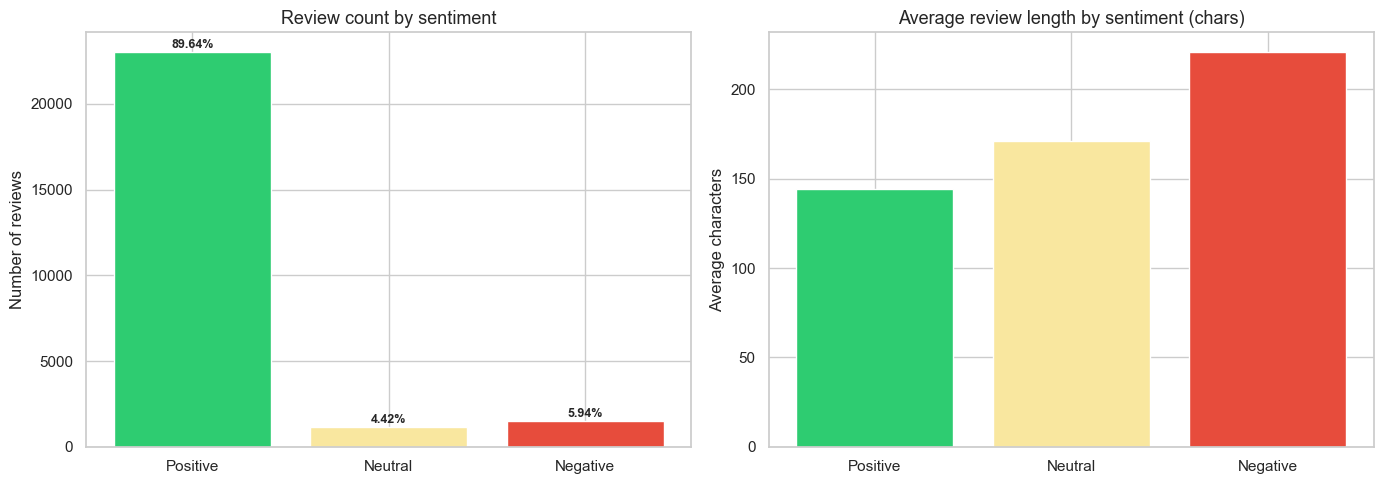

In [3]:
sql_dist = '''
SELECT
    sentiment,
    COUNT(*)                                              AS review_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2)    AS pct
FROM reviews
WHERE review_text IS NOT NULL
GROUP BY sentiment
ORDER BY review_count DESC
'''

dist = run_query(sql_dist, 'sentiment_distribution')
print('Sentiment distribution:')
print(dist.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Positive': '#2ECC71', 'Neutral': '#F9E79F', 'Negative': '#E74C3C'}

# Count by class
ordered = ['Positive', 'Neutral', 'Negative']
counts  = [int(dist[dist['sentiment'] == s]['review_count'].values[0]) for s in ordered]
pcts    = [float(dist[dist['sentiment'] == s]['pct'].values[0])         for s in ordered]
axes[0].bar(ordered, counts, color=[colors[s] for s in ordered])
axes[0].set_title('Review count by sentiment', fontsize=13)
axes[0].set_ylabel('Number of reviews')
for i, (n, p) in enumerate(zip(counts, pcts)):
    axes[0].text(i, n + max(counts) * 0.01, f'{p}%',
                 ha='center', fontsize=9, fontweight='bold')

# Average review length by sentiment
len_by_sent = reviews.groupby('sentiment')['review_length'].mean().reindex(ordered)
axes[1].bar(ordered, len_by_sent.values, color=[colors[s] for s in ordered])
axes[1].set_title('Average review length by sentiment (chars)', fontsize=13)
axes[1].set_ylabel('Average characters')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p5_sentiment_distribution.png'), dpi=150)
plt.show()

---
## 4. Text preprocessing
Standard NLP pipeline: lowercase, strip URLs and punctuation, tokenise, remove stopwords (including marketing-noise words like *product*, *amazon*), then stem with Porter stemmer.

In [4]:
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Domain stopwords — these appear in every review regardless of sentiment
# and add no discriminating signal
stop_words.update({
    'product', 'item', 'bought', 'buy', 'purchase', 'ordered',
    'amazon', 'price', 'shipping', 'arrived', 'received', 'use',
    'used', 'using', 'one', 'get', 'got', 'would', 'could',
    'also', 'even', 'still', 'well', 'just', 'like', 'really'
})

def preprocess_text(t):
    t = str(t)
    if not t.strip() or t in ('nan', 'None', ''):
        return ''
    t = t.lower()
    t = re.sub(r'http\S+|www\S+', '', t)
    t = re.sub(r'[^a-z\s]', '', t)
    tokens = word_tokenize(t)
    tokens = [tok for tok in tokens if tok not in stop_words and len(tok) > 2]
    tokens = [stemmer.stem(tok) for tok in tokens]
    return ' '.join(tokens)

print('Preprocessing review text...')
reviews['clean_text'] = reviews['review_text'].apply(preprocess_text).astype(object)

before  = len(reviews)
reviews = reviews[reviews['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'Reviews removed (empty after preprocessing): {before - len(reviews):,}')
print(f'Reviews remaining for modelling: {len(reviews):,}')

sample = reviews.sample(1, random_state=42).iloc[0]
print(f'\nExample:')
print(f'  Original:  {str(sample["review_text"])[:200]}')
print(f'  Processed: {str(sample["clean_text"])[:200]}')

Preprocessing review text...
Reviews removed (empty after preprocessing): 5
Reviews remaining for modelling: 25,668

Example:
  Original:  I used these in wireless microphones in church. They didn't last as long as I expected. Actually, rechargeable batteries do nearly as well.
  Processed: wireless microphon church didnt last long expect actual recharg batteri nearli


---
## 5. TF-IDF vectorisation & train/test split
Stratified 80/20 split preserves the class distribution in both sets. TF-IDF with unigrams + bigrams captures both individual words and short phrases (e.g. *"last long"* as a complaint signal).

In [5]:
X = reviews['clean_text'].to_numpy(dtype=str)
y = reviews['sentiment'].to_numpy(dtype=str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train):,} reviews')
print(f'Test set:     {len(X_test):,} reviews')
print(f'\nTraining class distribution:')
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  {cls:<10} {cnt:>6,} ({cnt/len(y_train)*100:.1f}%)')

# TF-IDF
# - max_features=10000 keeps the vocabulary manageable
# - ngram_range=(1, 2) captures phrases as well as single words
# - min_df=3 drops rare terms appearing in fewer than 3 reviews
# - sublinear_tf=True dampens the weight of very frequent terms
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'\nTF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test):  {X_test_tfidf.shape}')

Training set: 20,534 reviews
Test set:     5,134 reviews

Training class distribution:
  Negative    1,219 (5.9%)
  Neutral       908 (4.4%)
  Positive   18,407 (89.6%)

TF-IDF matrix shape (train): (20534, 10000)
TF-IDF matrix shape (test):  (5134, 10000)


---
## 6. Train all three classifiers
Naive Bayes uses smoothing only — it doesn't support class weighting. Logistic Regression and Linear SVC use `class_weight='balanced'` to compensate for the 90/5/5 imbalance. Linear SVC is wrapped in `CalibratedClassifierCV` so it can produce probability outputs for AUC-ROC.

In [6]:
classes = sorted(np.unique(y_train).tolist())
print(f'Classes: {classes}')

classifiers = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000,
        random_state=42, C=1.0
    ),
    'Linear SVC': CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=2000,
                  random_state=42, C=1.0)
    )
}

predictions   = {}
probabilities = {}

for name, clf in classifiers.items():
    clf.fit(X_train_tfidf, y_train)
    predictions[name]   = clf.predict(X_test_tfidf)
    probabilities[name] = clf.predict_proba(X_test_tfidf)
    print(f'{name:<22} trained ✅')

Classes: ['Negative', 'Neutral', 'Positive']
Naive Bayes            trained ✅
Logistic Regression    trained ✅
Linear SVC             trained ✅


---
## 7. Evaluation step 1 — confusion matrices for every model
Confusion matrices come first. They show **exactly where each model makes errors** before any summary metric can hide them. Look at the bottom-left rows of each matrix — those are the Negative actuals. The Negative→Negative diagonal cell is what we ultimately care about for complaint identification.

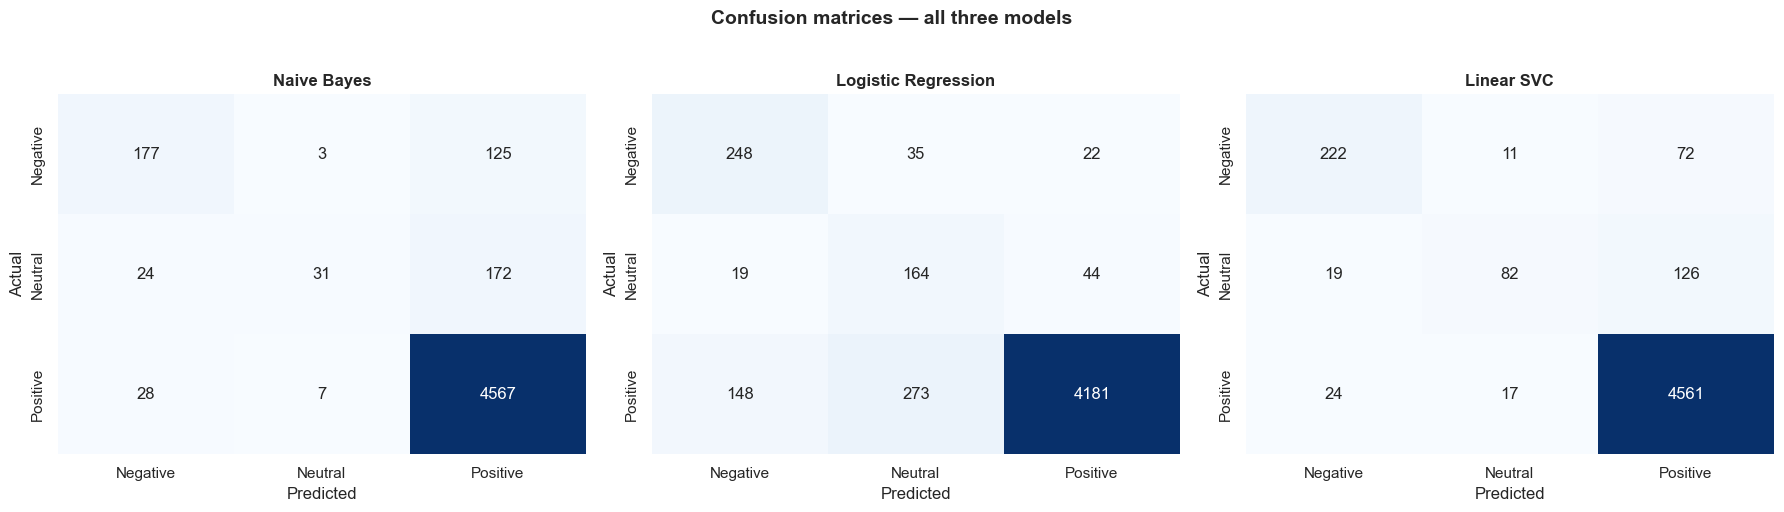

Negative-actual breakdown per model (the row that matters for complaint catching):
Model                    caught   missed→Neu   missed→Pos    total   recall
----------------------------------------------------------------------------
Naive Bayes                 177            3          125      305   58.03%
Logistic Regression         248           35           22      305   81.31%
Linear SVC                  222           11           72      305   72.79%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion matrices — all three models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p5_confusion_matrices_all.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Raw counts of Negative-actual outcomes — the row that matters for complaint catching
print('Negative-actual breakdown per model (the row that matters for complaint catching):')
print(f'{"Model":<22} {"caught":>8} {"missed→Neu":>12} {"missed→Pos":>12} {"total":>8} {"recall":>8}')
print('-' * 76)
for name, preds in predictions.items():
    cm = confusion_matrix(y_test, preds, labels=classes)
    neg_idx = classes.index('Negative')
    neu_idx = classes.index('Neutral')
    pos_idx = classes.index('Positive')
    caught = cm[neg_idx, neg_idx]
    to_neu = cm[neg_idx, neu_idx]
    to_pos = cm[neg_idx, pos_idx]
    total  = caught + to_neu + to_pos
    recall = caught / total if total else 0
    print(f'{name:<22} {caught:>8} {to_neu:>12} {to_pos:>12} {total:>8} {recall:>8.2%}')

---
## 8. Evaluation step 2 — full classification reports
Per-class precision, recall, and F1 for every model. The headline metric to watch is **Negative recall** — it's the fraction of actual complaints each model catches.

In [8]:
for name, preds in predictions.items():
    print('=' * 60)
    print(f'Classification report — {name}')
    print('=' * 60)
    print(classification_report(
        y_test, preds, target_names=classes, digits=4
    ))

Classification report — Naive Bayes
              precision    recall  f1-score   support

    Negative     0.7729    0.5803    0.6629       305
     Neutral     0.7561    0.1366    0.2313       227
    Positive     0.9389    0.9924    0.9649      4602

    accuracy                         0.9301      5134
   macro avg     0.8227    0.5698    0.6197      5134
weighted avg     0.9210    0.9301    0.9146      5134

Classification report — Logistic Regression
              precision    recall  f1-score   support

    Negative     0.5976    0.8131    0.6889       305
     Neutral     0.3475    0.7225    0.4692       227
    Positive     0.9845    0.9085    0.9450      4602

    accuracy                         0.8946      5134
   macro avg     0.6432    0.8147    0.7010      5134
weighted avg     0.9333    0.8946    0.9087      5134

Classification report — Linear SVC
              precision    recall  f1-score   support

    Negative     0.8377    0.7279    0.7789       305
     Neutral  

---
## 9. Evaluation step 3 — AUC-ROC and summary table
AUC-ROC measures ranking quality across all classes. We compute it last — only after the confusion matrices and classification reports have shown what each model actually does on each class.

In [9]:
y_bin = label_binarize(y_test, classes=classes)
neg_idx = classes.index('Negative')
neu_idx = classes.index('Neutral')

rows = []
for name, preds in predictions.items():
    proba = probabilities[name]
    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_bin, proba, multi_class='ovr', average='macro')
    neg_recall = recall_score(y_test, preds, labels=['Negative'], average='macro')
    neu_recall = recall_score(y_test, preds, labels=['Neutral'],  average='macro')
    pos_recall = recall_score(y_test, preds, labels=['Positive'], average='macro')
    rows.append({
        'Model':            name,
        'Accuracy':         round(acc, 4),
        'AUC-ROC (macro)':  round(auc, 4),
        'Negative recall':  round(neg_recall, 4),
        'Neutral recall':   round(neu_recall, 4),
        'Positive recall':  round(pos_recall, 4),
    })

summary_df = pd.DataFrame(rows)
print('Full evaluation table:')
print(summary_df.to_string(index=False))

Full evaluation table:
              Model  Accuracy  AUC-ROC (macro)  Negative recall  Neutral recall  Positive recall
        Naive Bayes    0.9301           0.9376           0.5803          0.1366           0.9924
Logistic Regression    0.8946           0.9356           0.8131          0.7225           0.9085
         Linear SVC    0.9476           0.9367           0.7279          0.3612           0.9911


---
## 10. Model selection — by stated business objective
The original business question is *"which sentiment model best identifies complaints?"* — that means **Negative recall is the ranking metric**, with AUC-ROC as a tiebreaker. Accuracy on a 90/5/5 imbalance is dominated by the Positive majority and doesn't measure the thing we care about.

In [10]:
# Rank by Negative recall first, AUC-ROC second
candidates = summary_df.sort_values(
    by=['Negative recall', 'AUC-ROC (macro)'],
    ascending=[False, False]
).reset_index(drop=True)

print('Candidate ranking — (Negative recall → AUC-ROC):')
print(candidates.to_string(index=False))

best_name = candidates.iloc[0]['Model']
best_clf  = classifiers[best_name]
best_preds = predictions[best_name]

# Compute the "complaints caught" delta vs the next-best model
next_name = candidates.iloc[1]['Model']
best_neg_recall   = candidates.iloc[0]['Negative recall']
next_neg_recall   = candidates.iloc[1]['Negative recall']
n_negative_actual = (y_test == 'Negative').sum()
delta_caught      = round((best_neg_recall - next_neg_recall) * n_negative_actual)

print(f'\n→ Selected model: {best_name}')
print(f'   Negative recall:   {best_neg_recall:.4f}')
print(f'   AUC-ROC (macro):   {candidates.iloc[0]["AUC-ROC (macro)"]:.4f}')
print(f'   Accuracy:          {candidates.iloc[0]["Accuracy"]:.4f}')
print(f'\n   vs next-best {next_name}: catches ~{delta_caught} more complaints')
print(f'   out of {n_negative_actual} actual Negative reviews in the test set.')

Candidate ranking — (Negative recall → AUC-ROC):
              Model  Accuracy  AUC-ROC (macro)  Negative recall  Neutral recall  Positive recall
Logistic Regression    0.8946           0.9356           0.8131          0.7225           0.9085
         Linear SVC    0.9476           0.9367           0.7279          0.3612           0.9911
        Naive Bayes    0.9301           0.9376           0.5803          0.1366           0.9924

→ Selected model: Logistic Regression
   Negative recall:   0.8131
   AUC-ROC (macro):   0.9356
   Accuracy:          0.8946

   vs next-best Linear SVC: catches ~26 more complaints
   out of 305 actual Negative reviews in the test set.


### Note on the trade-off
The selected model has lower overall accuracy than the alternatives. That's the right trade for this objective: on a 90/5/5 dataset, accuracy is mostly a measure of how well the model handles the Positive class — but the Positive class isn't what we need to catch. **Complaints (Negative) are the actionable signal**, and selecting on Negative recall directly optimises for finding them.

---
## 11. Most informative words per sentiment class
We take the highest mean TF-IDF score per term within each class. These are the words that most distinguish each sentiment.

In [11]:
feature_names = vectorizer.get_feature_names_out()
top_words = {}

for sentiment in classes:
    mask        = y_train == sentiment
    subset      = X_train_tfidf[mask]
    mean_scores = np.asarray(subset.mean(axis=0)).flatten()
    top_idx     = mean_scores.argsort()[-15:][::-1]
    top_words[sentiment] = [
        (feature_names[i], round(float(mean_scores[i]), 4))
        for i in top_idx
    ]

for sentiment, words in top_words.items():
    print(f'\nTop words — {sentiment}:')
    for w, s in words:
        print(f'  {w:<25} {s:.4f}')


Top words — Negative:
  batteri                   0.0645
  last                      0.0496
  dont                      0.0345
  long                      0.0261
  week                      0.0237
  work                      0.0224
  last long                 0.0223
  dead                      0.0209
  dont last                 0.0207
  return                    0.0178
  brand                     0.0175
  disappoint                0.0175
  day                       0.0168
  remot                     0.0166
  charg                     0.0163

Top words — Neutral:
  last                      0.0336
  batteri                   0.0325
  long                      0.0309
  last long                 0.0279
  good                      0.0267
  tablet                    0.0252
  dont                      0.0245
  work                      0.0192
  dont last                 0.0156
  seem                      0.0152
  duracel                   0.0140
  app                       0.0138
  kid     

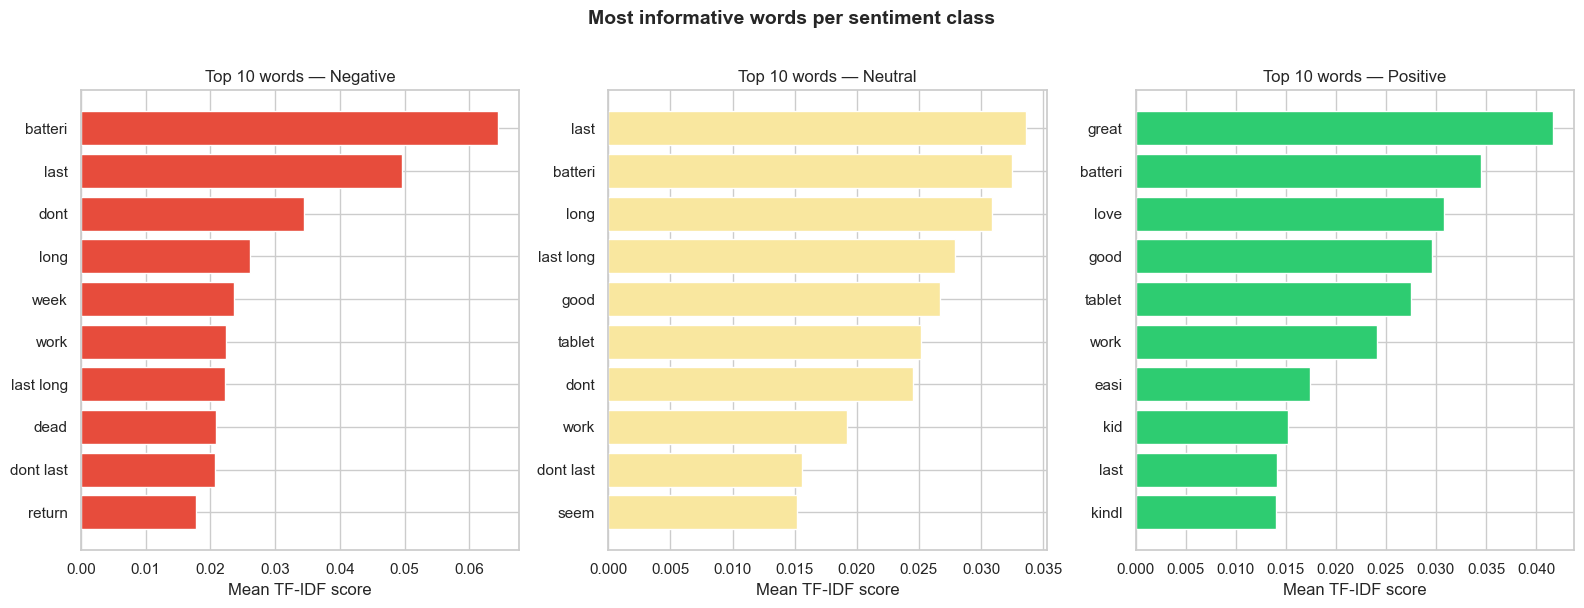

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
palette = {'Positive': '#2ECC71', 'Neutral': '#F9E79F', 'Negative': '#E74C3C'}

for ax, sentiment in zip(axes, classes):
    words  = [w for w, _ in top_words[sentiment][:10]]
    scores = [s for _, s in top_words[sentiment][:10]]
    ax.barh(words[::-1], scores[::-1], color=palette.get(sentiment))
    ax.set_title(f'Top 10 words — {sentiment}', fontsize=12)
    ax.set_xlabel('Mean TF-IDF score')

plt.suptitle('Most informative words per sentiment class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p5_top_words.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### Reading the words — the dominant complaint theme
The Negative class top words are visibly themed: *batteri, last, long, dead, dont last, week, return, disappoint*. Customers complaining about Amazon products are overwhelmingly complaining about **battery life**, not packaging, not delivery, not price. That's a single dominant product-quality signal worth taking to the product team.

The Neutral class shares vocabulary heavily with Negative (*batteri, last, dont, work, slow*) — which is why Neutral is the hardest class to classify. Neutral reviews are essentially "concerns without anger" and use the same vocabulary as full complaints, just with less intensity.

---
## 12. Word clouds — Positive and Negative

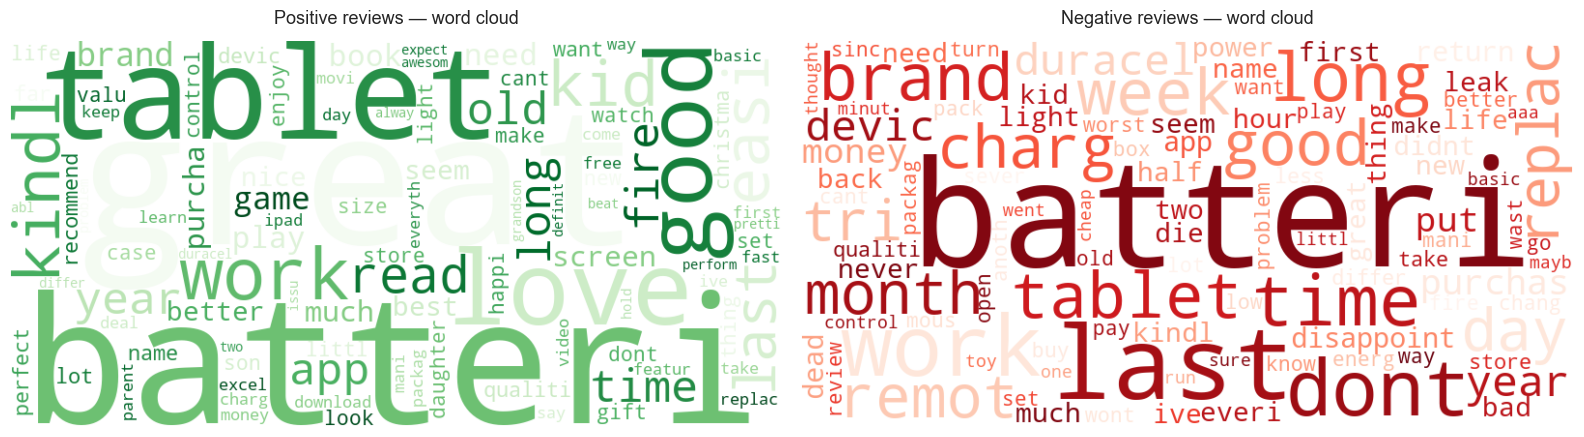

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sentiment, cmap in zip(
    axes, ['Positive', 'Negative'], ['Greens', 'Reds']
):
    text_blob = ' '.join(
        str(t) for t in reviews[reviews['sentiment'] == sentiment]['clean_text'].values
    )
    if not text_blob.strip():
        ax.text(0.5, 0.5, f'No {sentiment} text', ha='center', va='center',
                transform=ax.transAxes)
        ax.axis('off')
        continue

    wc = WordCloud(
        width=800, height=400, background_color='white',
        colormap=cmap, max_words=100, collocations=False
    ).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} reviews — word cloud', fontsize=13, pad=12)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p5_word_clouds.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 13. SQL — sentiment by product category
Which product categories carry the most customer complaints? Filtering to categories with at least 100 reviews so the percentages are statistically meaningful.

In [14]:
sql_cat = '''
SELECT
    category,
    COUNT(*)                                                  AS total_reviews,
    SUM(CASE WHEN sentiment = 'Positive' THEN 1 ELSE 0 END)   AS positive,
    SUM(CASE WHEN sentiment = 'Neutral'  THEN 1 ELSE 0 END)   AS neutral,
    SUM(CASE WHEN sentiment = 'Negative' THEN 1 ELSE 0 END)   AS negative,
    ROUND(
        SUM(CASE WHEN sentiment = 'Negative' THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*)::NUMERIC, 2
    )                                                         AS negative_pct,
    ROUND(AVG(rating)::NUMERIC, 2)                            AS avg_rating
FROM reviews
WHERE category IS NOT NULL AND TRIM(category) != ''
GROUP BY category
HAVING COUNT(*) >= 100
ORDER BY negative_pct DESC
LIMIT 10
'''

cat_sentiment = run_query(sql_cat, 'sentiment_by_category')
print('Sentiment by product category (top 10 by negative %):')
print(cat_sentiment.to_string(index=False))

Sentiment by product category (top 10 by negative %):
                   category  total_reviews  positive  neutral  negative  negative_pct  avg_rating
            Health & Beauty           9465      7905      470      1090         11.52        4.37
   Toys & Games,Electronics           1663      1518       91        54          3.25        4.53
                Electronics          13955     13039      546       370          2.65        4.56
          Electronics,Media            185       178        3         4          2.16        4.66
Office Supplies,Electronics            386       355       24         7          1.81        4.55


In [15]:
sql_rating = '''
SELECT
    sentiment,
    COUNT(*)                                AS review_count,
    ROUND(AVG(rating)::NUMERIC, 2)          AS avg_rating,
    ROUND(AVG(review_length)::NUMERIC, 0)   AS avg_length
FROM reviews
GROUP BY sentiment
ORDER BY avg_rating DESC
'''

rating_sentiment = run_query(sql_rating, 'sentiment_rating_profile')
print('Sentiment profile by rating and length:')
print(rating_sentiment.to_string(index=False))

Sentiment profile by rating and length:
sentiment  review_count  avg_rating  avg_length
 Positive         23013        4.77       144.0
  Neutral          1135        3.00       171.0
 Negative          1525        1.39       221.0


---
## 14. Save model outputs

In [16]:
summary_df.to_csv(
    os.path.join(PROCESSED_PATH, 'sentiment_model_comparison.csv'),
    index=False
)

top_words_rows = []
for sentiment, words in top_words.items():
    for rank, (w, s) in enumerate(words, 1):
        top_words_rows.append({
            'sentiment': sentiment, 'rank': rank,
            'word': w, 'tfidf_score': s
        })
pd.DataFrame(top_words_rows).to_csv(
    os.path.join(PROCESSED_PATH, 'sentiment_top_words.csv'), index=False
)

print('✅ sentiment_model_comparison.csv saved')
print('✅ sentiment_top_words.csv saved')

✅ sentiment_model_comparison.csv saved
✅ sentiment_top_words.csv saved


---
## 15. Phase 5 summary

In [17]:
selected = summary_df[summary_df['Model'] == best_name].iloc[0]
top_cat  = cat_sentiment.iloc[0]

print('=' * 64)
print('PHASE 5 SUMMARY — SENTIMENT ANALYSIS')
print('=' * 64)
print()
print('--- Dataset ---')
print(f'Total reviews modelled:    {len(reviews):,}')
for s in ['Positive', 'Neutral', 'Negative']:
    n   = int((reviews['sentiment'] == s).sum())
    pct = n / len(reviews) * 100
    print(f'  {s:<12}            {n:>6,} ({pct:.1f}%)')
print()
print('--- All models, evaluation in correct order ---')
print(summary_df[['Model', 'Accuracy', 'AUC-ROC (macro)',
                  'Negative recall', 'Neutral recall']].to_string(index=False))
print()
print(f'--- Production model: {best_name} ---')
print(f'Negative recall (complaints caught): {selected["Negative recall"]:.4f}')
print(f'Neutral recall:                       {selected["Neutral recall"]:.4f}')
print(f'Positive recall:                      {selected["Positive recall"]:.4f}')
print(f'Accuracy:                             {selected["Accuracy"]:.4f}')
print(f'AUC-ROC (macro):                      {selected["AUC-ROC (macro)"]:.4f}')
print()
print('--- Qualitative insight ---')
print('Dominant complaint theme: BATTERY LIFE.')
print('Top Negative words: battery, last, long, dead, "don\'t last", week, return, disappoint.')
print(f'Worst category by complaint rate: {top_cat["category"]} '
      f'({top_cat["negative_pct"]}% Negative).')
print()
print('--- Outputs ---')
print('  sentiment_model_comparison.csv')
print('  sentiment_top_words.csv')
print(f'  SQL queries documented in sql/queries/')
print('=' * 64)
print()
print('✅ Phase 5 complete. Proceed to Phase 6 — Market basket analysis.')

PHASE 5 SUMMARY — SENTIMENT ANALYSIS

--- Dataset ---
Total reviews modelled:    25,668
  Positive                23,009 (89.6%)
  Neutral                  1,135 (4.4%)
  Negative                 1,524 (5.9%)

--- All models, evaluation in correct order ---
              Model  Accuracy  AUC-ROC (macro)  Negative recall  Neutral recall
        Naive Bayes    0.9301           0.9376           0.5803          0.1366
Logistic Regression    0.8946           0.9356           0.8131          0.7225
         Linear SVC    0.9476           0.9367           0.7279          0.3612

--- Production model: Logistic Regression ---
Negative recall (complaints caught): 0.8131
Neutral recall:                       0.7225
Positive recall:                      0.9085
Accuracy:                             0.8946
AUC-ROC (macro):                      0.9356

--- Qualitative insight ---
Dominant complaint theme: BATTERY LIFE.
Top Negative words: battery, last, long, dead, "don't last", week, return, disappo